In [ ]:
%pip install opencv-python scikit-image pywavelets matplotlib pandas

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt
import pandas as pd
import os
import zipfile
import shutil

from skimage.metrics import structural_similarity as ssim

**Upload (Image OR Zip Folder)**

In [ ]:
from pathlib import Path

input_path = os.environ.get("IMAGE_INPUT_PATH")
if not input_path:
    raise RuntimeError("Set IMAGE_INPUT_PATH to a ZIP file, image file, or image directory before running the notebook.")

input_path = Path(input_path)
if input_path.is_dir():
    img_dir = str(input_path)
elif input_path.suffix.lower() == ".zip":
    with zipfile.ZipFile(input_path, "r") as zip_ref:
        zip_ref.extractall("dataset")
    img_dir = "dataset"
else:
    os.makedirs("dataset", exist_ok=True)
    target = Path("dataset") / input_path.name
    shutil.copy2(input_path, target)
    img_dir = "dataset"

print("Dataset path:", img_dir)

Saving Dataset_low_images.zip to Dataset_low_images.zip
Dataset path: dataset


**Load Images**

In [20]:
image_files = []

for root, dirs, files in os.walk(img_dir):
    for f in files:
        if f.lower().endswith((".png",".jpg",".jpeg")):
            image_files.append(os.path.join(root,f))

print("Total images:", len(image_files))

Total images: 15


**METRICS FUNCTION**

In [21]:
def compute_metrics(ref, img):

    ref = ref.astype(np.float32)
    img = img.astype(np.float32)

    mse = np.mean((ref - img) ** 2)

    if mse == 0:
        p = 100
    else:
        p = 10 * np.log10((255**2)/mse)

    s = ssim(ref, img, channel_axis=2, data_range=255)

    hist = cv2.calcHist([img],[0],None,[256],[0,256])
    prob = hist / np.sum(hist)
    prob = prob[prob > 0]
    entropy = -np.sum(prob * np.log2(prob))

    contrast = np.std(img)

    return p, s, entropy, contrast

**BASIC METHODS**

In [ ]:
def apply_HE(img):
    yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    yuv[:,:,0] = cv2.equalizeHist(yuv[:,:,0])
    return cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

def apply_CLAHE(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l,a,b = cv2.split(lab)
    clahe = cv2.createCLAHE(2.0,(8,8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l,a,b)), cv2.COLOR_LAB2RGB)

def apply_RD(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)

    L = L.astype(np.float32) / 255.0
    blur = cv2.GaussianBlur(L, (5,5), 0)

    rd = np.log1p(L) - np.log1p(blur + 1e-6)
    rd = cv2.normalize(rd, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    lab = cv2.merge([rd, A, B])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def apply_ESIHE(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    mean = int(np.mean(gray))

    lower = np.clip(gray, 0, mean)
    upper = np.clip(gray, mean, 255)

    lower_eq = cv2.equalizeHist(lower)
    upper_eq = cv2.equalizeHist(upper)

    result = cv2.addWeighted(lower_eq, 0.5, upper_eq, 0.5, 0)

    # 🔥 convert back to RGB
    return cv2.cvtColor(result, cv2.COLOR_GRAY2RGB)

def apply_RGHS(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)

    L_norm = cv2.normalize(L, None, 0, 255, cv2.NORM_MINMAX)
    L = cv2.addWeighted(L, 0.7, L_norm, 0.3, 0)  # 🔥 blend (important)

    lab = cv2.merge([L.astype(np.uint8), A, B])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

**OUR METHOD**

In [ ]:
def our_method(img):

    img_f = img.astype(np.float32) / 255.0
    output = np.zeros_like(img_f)

    for c in range(3):

        channel = img_f[:, :, c]

        # -------- WAVELET --------
        LL, (LH, HL, HH) = pywt.dwt2(channel, 'haar')

        # -------- LOW FREQUENCY --------
        LL = cv2.bilateralFilter(LL.astype(np.float32), d=5, sigmaColor=50, sigmaSpace=50)
        LL = np.maximum(LL, 1e-6)

        # Retinex
        log_LL = np.log1p(LL)
        blur = cv2.GaussianBlur(LL, (3,3), 0.5)
        LL_retinex = log_LL - 0.7 * np.log1p(blur + 1e-6)

        # -------- HE (instead of CLAHE) --------
        LL_norm = cv2.normalize(LL_retinex, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        LL_he = cv2.equalizeHist(LL_norm)

        # Blend (important)
        LL_he = cv2.addWeighted(LL_norm, 0.6, LL_he, 0.4, 0)
        LL_he = LL_he.astype(np.float32) / 255.0

        # -------- HIGH FREQUENCY --------
        def threshold(x):
            T = 0.2 * np.std(x)
            return np.where(np.abs(x) > T, x, 0)

        LH = threshold(LH)
        HL = threshold(HL)
        HH = threshold(HH)

        # -------- RECONSTRUCTION --------
        rec = pywt.idwt2((LL_he, (LH, HL, HH)), 'haar')
        rec = cv2.resize(rec, (img.shape[1], img.shape[0]))

        output[:, :, c] = rec

    # -------- FINAL --------
    output = np.clip(output, 0, 1)

    # Gamma boost
    output = np.power(output, 0.85)

    final = (output * 255).astype(np.uint8)

    # Sharpening
    kernel = np.array([[0,-1,0],
                       [-1,6,-1],
                       [0,-1,0]])

    final = cv2.filter2D(final, -1, kernel)

    return final

**FULL PIPELINE (STAGE-WISE)**

In [ ]:
def full_pipeline(img):

    stages = []

    original = img.copy()
    stages.append(("Original", original))

    he = apply_HE(original)
    stages.append(("HE", he))

    bilateral = cv2.bilateralFilter(he,5,75,75)
    stages.append(("Bilateral", bilateral))

    final = our_method(bilateral)
    stages.append(("Wavelet Fusion", final))

    return stages

**PROCESS ALL IMAGES**

In [ ]:
os.makedirs("outputs", exist_ok=True)
os.makedirs(os.path.join("outputs", "stages"), exist_ok=True)

results = []
stage_results = []

def ensure_rgb(img):
    if len(img.shape) == 2:
        return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return img

for path in image_files:

    img = cv2.imread(path)

    if img is None:
        print(f"Error loading {path}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    name = os.path.basename(path)

    # --- Method-wise results ---
    methods = {
        "Original": img,
        "HE": apply_HE(img),
        "CLAHE": apply_CLAHE(img),
        "RD": apply_RD(img),
        "ESIHE": apply_ESIHE(img),
        "RGHS": apply_RGHS(img),
        "Fusion": cv2.bilateralFilter(apply_HE(img), 5, 75, 75),
        "Our": our_method(img)
    }

    for m, out in methods.items():

        out = ensure_rgb(out)  # safety check

        save_path = f"outputs/{name}_{m}.png"
        cv2.imwrite(save_path, cv2.cvtColor(out, cv2.COLOR_RGB2BGR))

        try:
            p, s, e, c = compute_metrics(img, out)  # FIX: was `im` (undefined), corrected to `out`
        except Exception as ex:
            print("Metric error:", ex)
            continue

        results.append({
            "Image": name,
            "Method": m,
            "PSNR": p,
            "SSIM": s,
            "Entropy": e,
            "Contrast": c
        })

    # --- Stage-wise results (pipeline stages) ---
    stages = full_pipeline(img)

    for stage_name, stage_img in stages:
        stage_img = ensure_rgb(stage_img)
        try:
            p, s, e, c = compute_metrics(img, stage_img)
        except Exception as ex:
            print("Stage metric error:", ex)
            continue
        stage_results.append({
            "Image": name,
            "Stage": stage_name,
            "PSNR": p,
            "SSIM": s,
            "Entropy": e,
            "Contrast": c
        })


print("\n===== PER IMAGE METHOD METRICS =====\n")

df_methods = pd.DataFrame(results)

images = df_methods["Image"].unique()

for img_name in images:

    print(f"\n===== Image: {img_name} =====\n")

    temp = df_methods[df_methods["Image"] == img_name].copy()

    order = ["Original", "HE", "CLAHE", "RD", "ESIHE", "RGHS", "Fusion", "Our"]
    temp["Method"] = pd.Categorical(temp["Method"], categories=order, ordered=True)
    temp = temp.sort_values("Method")

    print(temp[["Method","PSNR","SSIM","Entropy","Contrast"]].round(3))

    print("\n" + "-"*60)

**PRINT PER IMAGE METHOD TABLE**

In [110]:
print("\n===== PER IMAGE METHOD METRICS =====\n")

df_methods = pd.DataFrame(results)

images = df_methods["Image"].unique()

for img_name in images:

    print(f"\n===== Image: {img_name} =====\n")

    temp = df_methods[df_methods["Image"] == img_name].copy()

    order = ["Original","HE","CLAHE","RD","ESIHE","RGHS","Fusion","Our"]
    temp["Method"] = pd.Categorical(temp["Method"], categories=order, ordered=True)
    temp = temp.sort_values("Method")

    print(temp[["Method","PSNR","SSIM","Entropy","Contrast"]].round(3))

    print("\n" + "-"*60)


===== PER IMAGE METHOD METRICS =====


===== Image: 10.png =====

     Method     PSNR   SSIM  Entropy   Contrast
0  Original  100.000  1.000    4.924   8.229000
1        HE    5.633  0.101    7.460  74.226997
2     CLAHE   23.755  0.724    5.656  15.019000
3        RD   41.873  0.946    4.824   7.804000
4     ESIHE    5.628  0.099    4.909  74.140999
5      RGHS   11.756  0.257    4.924  38.887001
6       Our   11.291  0.314    6.569  26.415001

------------------------------------------------------------

===== Image: 2.png =====

      Method     PSNR   SSIM  Entropy   Contrast
7   Original  100.000  1.000    5.305  13.257000
8         HE    6.109  0.130    7.445  75.120003
9      CLAHE   22.021  0.663    6.115  22.084000
10        RD   42.579  0.957    5.195  13.016000
11     ESIHE    6.110  0.128    5.169  75.001999
12      RGHS   13.614  0.465    5.305  43.339001
13       Our   13.993  0.441    6.589  32.376999

------------------------------------------------------------

=====

**AVERAGE**

In [ ]:
df = pd.DataFrame(results)

order = ["Original", "HE", "CLAHE", "RD", "ESIHE", "RGHS", "Fusion", "Our"]

table = df.groupby("Method").mean(numeric_only=True)
table = table.reindex(order)
table = table.replace(np.inf,100)

print("\n===== Comparison of various algorithms (AVERAGE) =====\n")
print(table.round(3))


===== Comparison of various algorithms (AVERAGE) =====

             PSNR   SSIM  Entropy   Contrast
Method                                      
Original  100.000  1.000    4.802  10.976000
HE          5.698  0.096    7.054  73.703003
CLAHE      23.973  0.658    5.621  17.415001
RD         41.142  0.949    4.718  10.455000
ESIHE       5.685  0.094    4.729  73.695999
RGHS       32.337  0.686    4.802  26.610001
Our        15.016  0.399    6.358  27.120001


**STAGE-WISE PRINT METRICS**

In [ ]:
print("\n===== STAGE-WISE METRICS (PER IMAGE) =====\n")

# ✅ Fix: check before using
if len(stage_results) == 0:
    print("❌ stage_results is empty")
else:
    df_stage = pd.DataFrame(stage_results)

    if "Image" not in df_stage.columns:
        print("❌ 'Image' column missing")
    else:
        images = df_stage["Image"].unique()

        for img_name in images:

            print(f"\n===== Image: {img_name} =====\n")

            temp_df = df_stage[df_stage["Image"] == img_name].copy()

            order = ["Original", "HE", "Bilateral", "Wavelet Fusion"]
            temp_df["Stage"] = pd.Categorical(temp_df["Stage"], categories=order, ordered=True)
            temp_df = temp_df.sort_values("Stage")

            print(temp_df[["Stage","PSNR","SSIM","Entropy","Contrast"]].round(3))

            print("\n" + "-"*60)


===== STAGE-WISE METRICS (PER IMAGE) =====


===== Image: 10.png =====

            Stage        PSNR      SSIM   Entropy   Contrast
0        Original  100.000000  1.000000  4.924193   8.228838
1              HE    5.633073  0.100641  7.459661  74.226677
2       Bilateral    5.650837  0.147099  7.945847  73.401855
3  Wavelet Fusion   10.397474  0.216022  6.981331  34.270859

------------------------------------------------------------

===== Image: 2.png =====

            Stage        PSNR      SSIM   Entropy   Contrast
4        Original  100.000000  1.000000  5.305084  13.257471
5              HE    6.108830  0.129658  7.444742  75.119781
6       Bilateral    6.129702  0.177989  7.945729  74.388756
7  Wavelet Fusion   11.269350  0.293923  6.937407  35.187141

------------------------------------------------------------

===== Image: 13.png =====

             Stage        PSNR      SSIM   Entropy   Contrast
8         Original  100.000000  1.000000  4.956907  10.042137
9             

# **Sample Image**

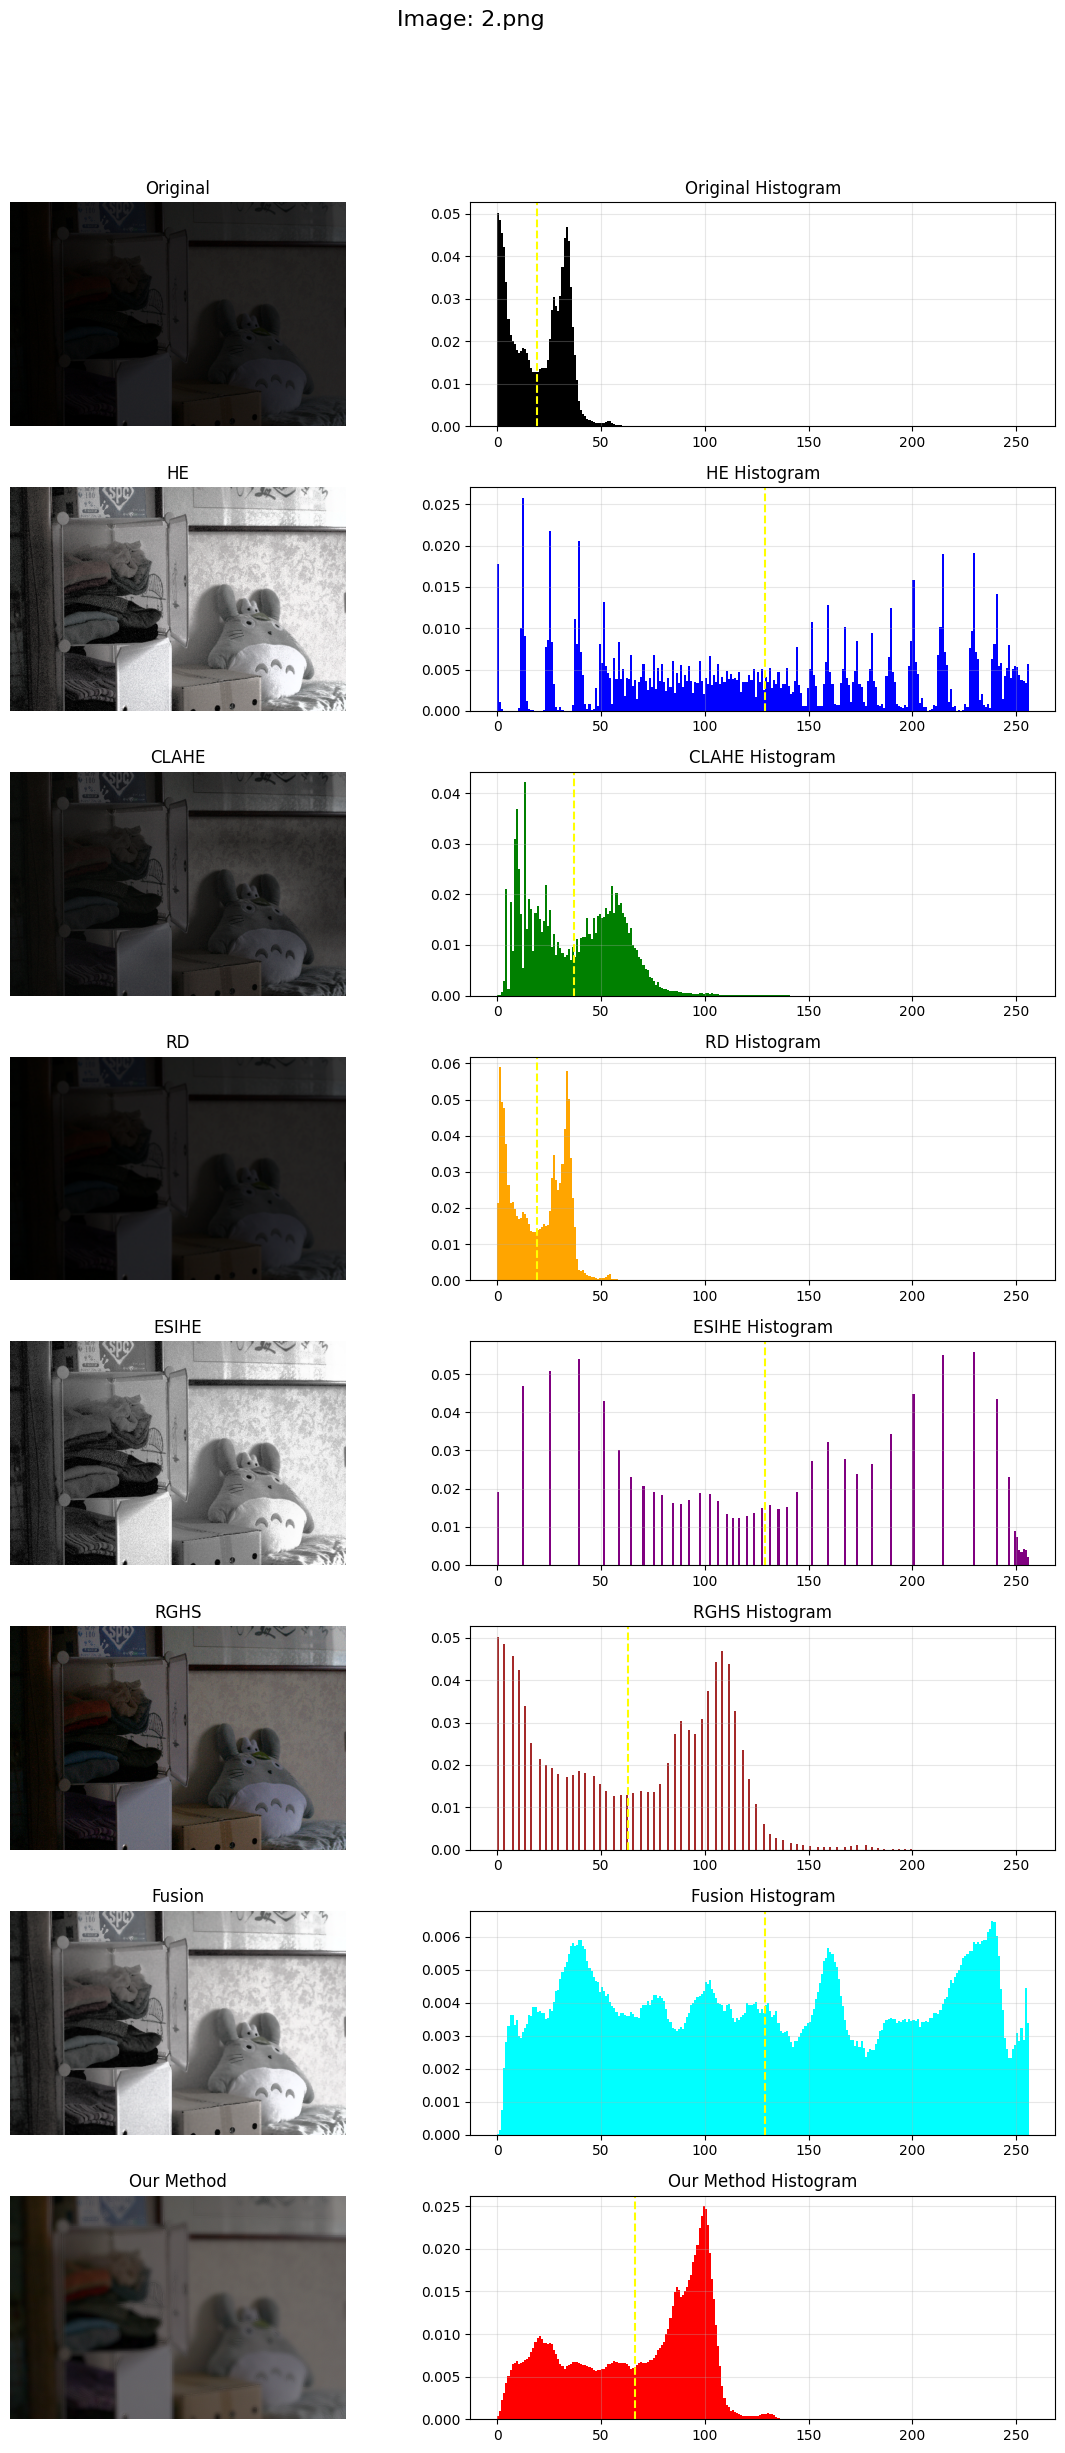

In [ ]:
# Select ONE image
if not image_files:
    raise RuntimeError("No images were found in IMAGE_INPUT_PATH.")

path = image_files[0]

img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -------- DEFINE FUSION (BASELINE) --------
def fusion_method(img):
    return cv2.bilateralFilter(apply_HE(img), 5, 75, 75)

# -------- COMPUTE ALL METHODS --------
methods = [
    ("Original", img, "black"),
    ("HE", apply_HE(img), "blue"),
    ("CLAHE", apply_CLAHE(img), "green"),
    ("RD", apply_RD(img), "orange"),
    ("ESIHE", apply_ESIHE(img), "purple"),  # FIX: apply_ESIHE already returns RGB
    ("RGHS", apply_RGHS(img), "brown"),
    ("Fusion", fusion_method(img), "cyan"),   # ADDED
    ("Our Method", our_method(img), "red")
]

rows = len(methods)

plt.figure(figsize=(12, rows * 3))

# -------- TITLE --------
plt.suptitle(f"Image: {os.path.basename(path)}", fontsize=16, y=1.02)

for i, (name, im, color) in enumerate(methods):

    # IMAGE
    plt.subplot(rows, 2, 2*i + 1)
    plt.imshow(im)
    plt.title(name)
    plt.axis('off')

    # HISTOGRAM
    plt.subplot(rows, 2, 2*i + 2)
    plt.hist(im.ravel(), bins=256, range=(0,256), density=True, color=color)
    plt.axvline(np.mean(im), color='yellow', linestyle='--')
    plt.grid(alpha=0.3)
    plt.title(f"{name} Histogram")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()